In [35]:
import pandas as pd
import matplotlib.pyplot as plt
#Show all rows (for checking)
pd.set_option('display.max_rows', None)

In [36]:
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)

        print("Data Loaded Successfully")
        print("Total Rows:", len(df))
        print("Total Columns:", len(df.columns))

        print("\nPreview:")
        print(df.head())

        return df

    except FileNotFoundError:
        print("File not found. Check path.")
    except Exception as e:
        print("Error:", e)

In [37]:
def clean_data(df):
    initial_rows = len(df)

    df = df.drop_duplicates()
    df = df.dropna()

    df['Date'] = pd.to_datetime(df['Date'])

    print("\n Data Cleaned")
    print("Rows removed:", initial_rows - len(df))
    print("Remaining rows:", len(df))

    return df

In [38]:
def process_data(df):
    df['Total'] = df['Price'] * df['Quantity']

    print("\n Data Processed (Total column added)")
    return df

In [39]:
def analyze_data(df):
    insights = {}

    insights['total_revenue'] = df['Total'].sum()
    insights['avg_order_value'] = df['Total'].mean()
    insights['top_product'] = df.groupby('Product_Name')['Total'].sum().idxmax()
    insights['category_sales'] = df.groupby('Category')['Total'].sum()

    print("\n Data Analysis Complete")

    return insights

In [40]:
def generate_report(df, insights):
    print("\n===== FINAL REPORT =====")

    print(f"Total Revenue: {insights['total_revenue']}")
    print(f"Average Order Value: {insights['avg_order_value']:.2f}")
    print(f"Top Product: {insights['top_product']}")

    print("\nCategory-wise Sales:")
    print(insights['category_sales'])

    # Save CSV
    df.to_csv("output.csv", index=False)

    print("\n Report saved as output.csv")

In [41]:
file_path = "sales1.csv"

df = load_data(file_path)
df = clean_data(df)
df = process_data(df)

insights = analyze_data(df)

generate_report(df, insights)

Data Loaded Successfully
Total Rows: 100
Total Columns: 6

Preview:
   Order_ID Product_Name     Category  Price  Quantity        Date
0         1       Laptop  Electronics  55000         1  2026-01-01
1         2   Smartphone  Electronics  20000         2  2026-01-02
2         3   Headphones  Electronics   3000         3  2026-01-03
3         4        Shoes      Fashion   2500         2  2026-01-04
4         5      T-shirt      Fashion   1200         4  2026-01-05

 Data Cleaned
Rows removed: 0
Remaining rows: 100

 Data Processed (Total column added)

 Data Analysis Complete

===== FINAL REPORT =====
Total Revenue: 1829500
Average Order Value: 18295.00
Top Product: Laptop

Category-wise Sales:
Category
Accessories     136500
Electronics    1514000
Fashion         179000
Name: Total, dtype: int64

 Report saved as output.csv


Data Loaded Successfully
Total Rows: 100
Total Columns: 6

Preview:
   Order_ID Product_Name     Category  Price  Quantity        Date
0         1       Laptop  Electronics  55000         1  2026-01-01
1         2   Smartphone  Electronics  20000         2  2026-01-02
2         3   Headphones  Electronics   3000         3  2026-01-03
3         4        Shoes      Fashion   2500         2  2026-01-04
4         5      T-shirt      Fashion   1200         4  2026-01-05

 Data Cleaned
Rows removed: 0
Remaining rows: 100

 Data Processed (Total column added)

 Data Analysis Complete

===== FINAL REPORT =====
Total Revenue: 1829500
Average Order Value: 18295.00
Top Product: Laptop

Category-wise Sales:
Category
Accessories     136500
Electronics    1514000
Fashion         179000
Name: Total, dtype: int64

 Report saved as output.csv


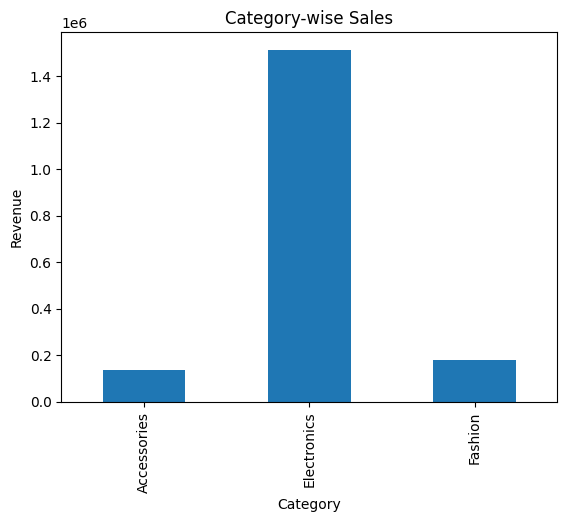

In [42]:
file_path = "sales1.csv"

df = load_data(file_path)

# Safety check
if df is not None:
    df = clean_data(df)
    df = process_data(df)

    insights = analyze_data(df)

    generate_report(df, insights)

    # Optional
    plot_data(df)

In [43]:
def plot_data(df):
    df.groupby('Category')['Total'].sum().plot(kind='bar')

    plt.title("Category-wise Sales")
    plt.xlabel("Category")
    plt.ylabel("Revenue")

    plt.show()